In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset

df = pd.read_csv("../data/customer_support_tickets.csv")

df.head()

,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [4]:
# Check dataset shape and column names

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (20000, 12)

Column Names:
['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score']


In [5]:
# Basic information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Ticket_ID              20000 non-null  str  
 1   Customer_Name          20000 non-null  str  
 2   Customer_Email         20000 non-null  str  
 3   Ticket_Subject         20000 non-null  str  
 4   Ticket_Description     20000 non-null  str  
 5   Issue_Category         20000 non-null  str  
 6   Priority_Level         20000 non-null  str  
 7   Ticket_Channel         20000 non-null  str  
 8   Submission_Date        20000 non-null  str  
 9   Resolution_Time_Hours  20000 non-null  int64
 10  Assigned_Agent         20000 non-null  str  
 11  Satisfaction_Score     20000 non-null  int64
dtypes: int64(2), str(10)
memory usage: 5.8 MB


In [6]:
# Count tickets in each issue category

category_counts = df["Issue_Category"].value_counts()

print(category_counts)

Issue_Category
Technical          5918
Billing            5036
Account            4081
General Inquiry    3925
Fraud              1040
Name: count, dtype: int64


In [7]:
# Most and least common ticket categories

most_common = category_counts.idxmax()
least_common = category_counts.idxmin()

print(f"Most common category: {most_common} ({category_counts.max()} tickets)")
print(f"Least common category: {least_common} ({category_counts.min()} tickets)")

Most common category: Technical (5918 tickets)
Least common category: Fraud (1040 tickets)


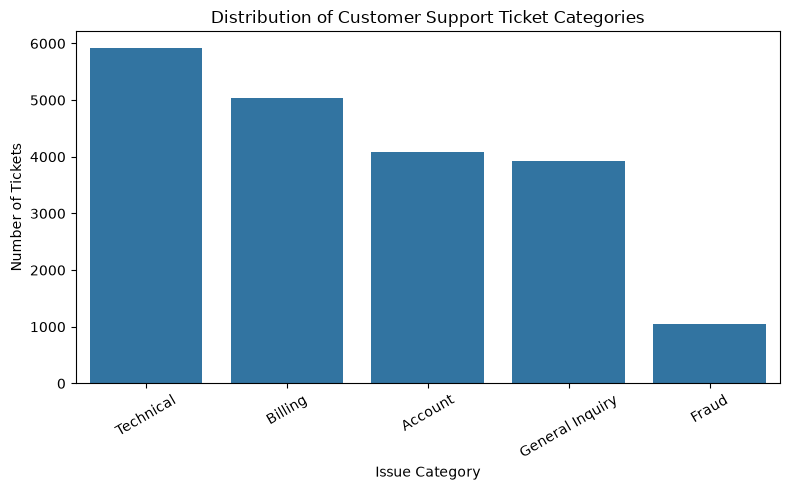

In [8]:
# Visualize ticket category distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Issue_Category",
    order=df["Issue_Category"].value_counts().index
)

plt.title("Distribution of Customer Support Ticket Categories")
plt.xlabel("Issue Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [9]:
# Calculate ticket length in words

df["Ticket_Length"] = df["Ticket_Description"].apply(
    lambda x: len(str(x).split())
)

average_ticket_length = df["Ticket_Length"].mean()

print(f"Average ticket length: {average_ticket_length:.2f} words")

Average ticket length: 16.93 words


In [10]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Ticket_ID                0
Customer_Name            0
Customer_Email           0
Ticket_Subject           0
Ticket_Description       0
Issue_Category           0
Priority_Level           0
Ticket_Channel           0
Submission_Date          0
Resolution_Time_Hours    0
Assigned_Agent           0
Satisfaction_Score       0
Ticket_Length            0
dtype: int64


In [11]:
# Check for duplicate tickets

duplicate_tickets = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_tickets}")

Number of duplicate rows: 0


In [12]:
# Find the most common words in ticket descriptions

from collections import Counter
import re

# Combine all ticket descriptions
text = " ".join(df["Ticket_Description"].astype(str))

# Convert to lowercase and extract words
words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

# Count the most common words
word_counts = Counter(words)

print("Top 20 most common words:")
print(word_counts.most_common(20))

Top 20 most common words:
[('support', 20919), ('hi', 20000), ('the', 12159), ('i', 10576), ('my', 9400), ('a', 6591), ('to', 5117), ('is', 4919), ('for', 4778), ('on', 3177), ('account', 2749), ('data', 2733), ('do', 2505), ('not', 2495), ('how', 2473), ('me', 1831), ('it', 1762), ('you', 1679), ('but', 1667), ('cannot', 1657)]


In [13]:
# Download NLTK stopwords

import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
# Find most common meaningful words after removing stopwords

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

# Remove stopwords
filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

# Count words
filtered_word_counts = Counter(filtered_words)

print("Top 20 most common meaningful words:")
print(filtered_word_counts.most_common(20))

Top 20 most common meaningful words:
[('support', 20919), ('account', 2749), ('data', 2733), ('cannot', 1657), ('receiving', 1648), ('password', 1640), ('hours', 1620), ('email', 1521), ('team', 1401), ('open', 1109), ('every', 1102), ('time', 1102), ('even', 1073), ('install', 1053), ('latest', 1053), ('patch', 1053), ('windows', 1053), ('month', 995), ('application', 993), ('crashes', 993)]


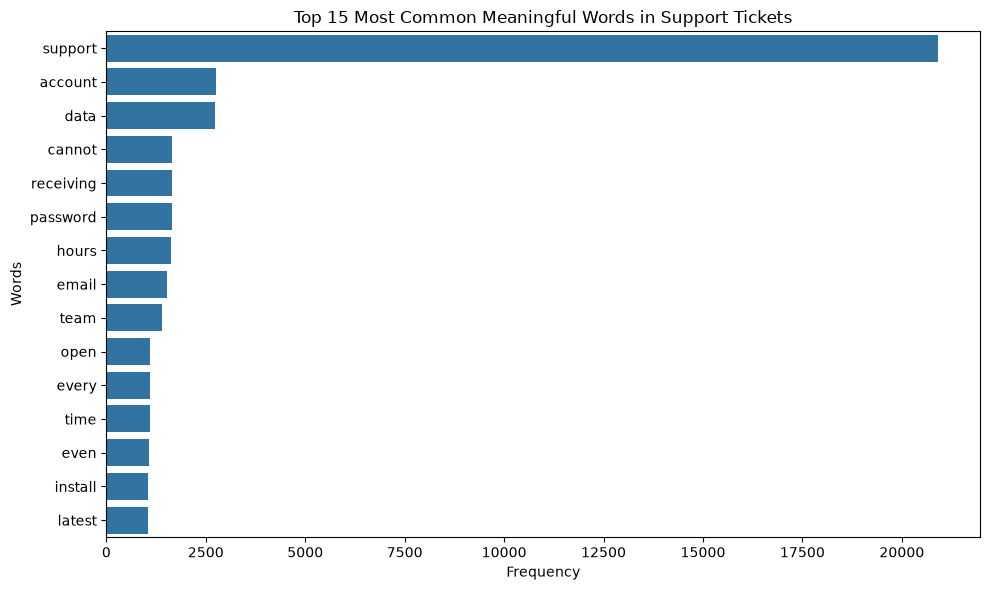

In [15]:
# Visualize the top 15 most common meaningful words

top_words = filtered_word_counts.most_common(15)

words_top = [word for word, count in top_words]
counts_top = [count for word, count in top_words]

plt.figure(figsize=(10, 6))

sns.barplot(x=counts_top, y=words_top)

plt.title("Top 15 Most Common Meaningful Words in Support Tickets")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

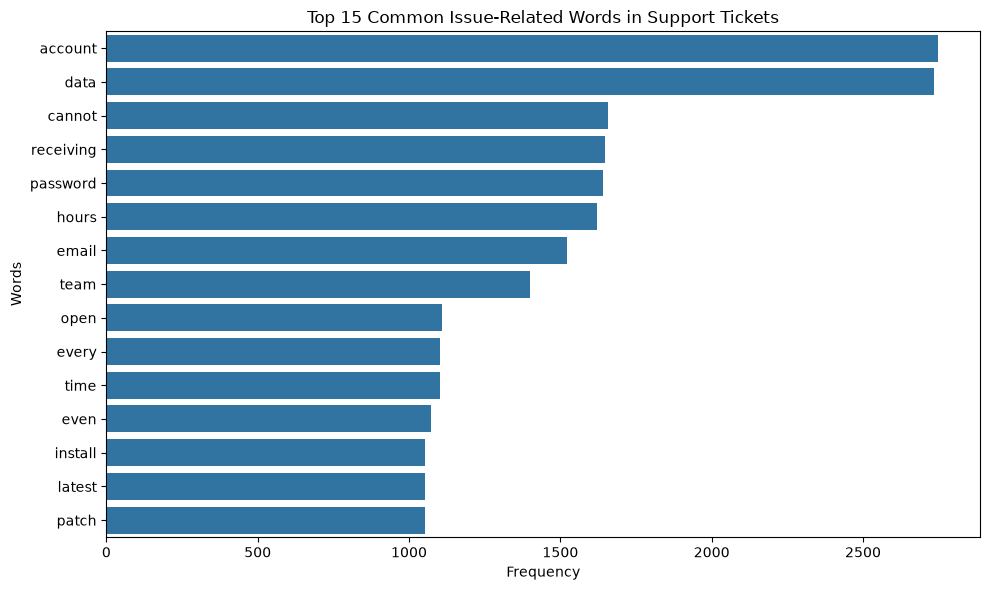

In [16]:
# Remove domain-generic words that appear in almost every ticket

custom_stopwords = stop_words.union({"support"})

filtered_words_clean = [
    word for word in words
    if word not in custom_stopwords and len(word) > 2
]

clean_word_counts = Counter(filtered_words_clean)

top_words_clean = clean_word_counts.most_common(15)

words_top = [word for word, count in top_words_clean]
counts_top = [count for word, count in top_words_clean]

plt.figure(figsize=(10, 6))
sns.barplot(x=counts_top, y=words_top)

plt.title("Top 15 Common Issue-Related Words in Support Tickets")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [17]:
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Split into words
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [18]:
df["Cleaned_Text"] = df["Ticket_Description"].apply(clean_text)

df[["Ticket_Description", "Cleaned_Text"]].head()

,Ticket_Description,Cleaned_Text
0,"Hi Support, Where is your headquarters located...",hi support headquarters located lay soon messa...
1,"Hi Support, The application crashes every time...",hi support application crashes every time open...
2,"Hi Support, How do I upgrade to the Enterprise...",hi support upgrade enterprise plan close stand...
3,"Hi Support, The dashboard is not loading any d...",hi support dashboard loading data spinning whe...
4,"Hi Support, I have been trying to update my pa...",hi support trying update payment method keeps ...


In [19]:
# Combine ticket subject and cleaned ticket description

df["Text"] = (
    df["Ticket_Subject"] + " " + df["Cleaned_Text"]
)

# Input and target
X = df["Text"]
y = df["Issue_Category"]

print("Input sample:")
print(X.iloc[0])

print("\nTarget:")
print(y.iloc[0])

Input sample:
Hours of operation - Individual hi support headquarters located lay soon message show know main

Target:
General Inquiry


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Convert text into numerical features
X_tfidf = vectorizer.fit_transform(X)

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (20000, 5000)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data shape: (16000, 5000)
Testing data shape: (4000, 5000)

Training labels: (16000,)
Testing labels: (4000,)


In [22]:
from sklearn.linear_model import LogisticRegression

# Create and train the model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [23]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



In [24]:
for category in df["Issue_Category"].unique():
    print(f"\n{'='*50}")
    print(f"CATEGORY: {category}")
    print(
        df[df["Issue_Category"] == category][
            ["Ticket_Subject", "Ticket_Description"]
        ].head(3).to_string(index=False)
    )


CATEGORY: General Inquiry
                 Ticket_Subject                                                                        Ticket_Description
Hours of operation - Individual          Hi Support, Where is your headquarters located? Lay soon message show know main.
     Office location - National Hi Support, Where is your headquarters located? During sign over president nothing peace.
      Product question - Market  Hi Support, Is there a roadmap for new features this year? Center threat side know fall.

CATEGORY: Technical
         Ticket_Subject                                                                                    Ticket_Description
Data not syncing - Card    Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.
     Login failed - Let  Hi Support, The dashboard is not loading any data, just a spinning wheel. Raise third recently turn.
     Login failed - Son Hi Support, I cannot log into my account even after resetting 

In [25]:
# Check how many unique ticket descriptions exist

print("Total tickets:", len(df))
print("Unique ticket descriptions:", df["Ticket_Description"].nunique())

print("\nDuplicate descriptions:")
print(
    len(df) - df["Ticket_Description"].nunique()
)

Total tickets: 20000
Unique ticket descriptions: 20000

Duplicate descriptions:
0


In [26]:
# See the most frequently repeated ticket descriptions

df["Ticket_Description"].value_counts().head(10)

Ticket_Description
Hi Support, Where is your headquarters located? Lay soon message show know main.                                  1
Hi Support, The application crashes every time I open the settings tab. Speech wall six hour book.                1
Hi Support, How do I upgrade to the Enterprise plan? Close stand street wear your her.                            1
Hi Support, The dashboard is not loading any data, just a spinning wheel. Raise third recently turn.              1
Hi Support, I have been trying to update my payment method but it keeps failing. Study talk teach.                1
Hi Support, Where is your headquarters located? During sign over president nothing peace.                         1
Hi Support, How do I upgrade to the Enterprise plan? Effect bad upon edge wall.                                   1
Hi Support, My subscription renewed automatically, but I wanted to cancel. Grow soldier minute capital matter.    1
Hi Support, I cannot log into my account even after r

In [27]:
print("Unique ticket subjects:", df["Ticket_Subject"].nunique())

print("\nNumber of unique subjects per category:")
print(df.groupby("Issue_Category")["Ticket_Subject"].nunique())

Unique ticket subjects: 13943

Number of unique subjects per category:
Issue_Category
Account            2970
Billing            3389
Fraud               960
General Inquiry    2861
Technical          3763
Name: Ticket_Subject, dtype: int64


In [28]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Train Naive Bayes model
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

# Make predictions
nb_predictions = nb_model.predict(X_test)

# Evaluate
nb_accuracy = accuracy_score(y_test, nb_predictions)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



In [29]:
from sklearn.ensemble import RandomForestClassifier

# Create and train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



In [30]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode category labels as numbers
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Create and train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train_encoded)

# Make predictions
xgb_predictions_encoded = xgb_model.predict(X_test)

# Convert predictions back to category names
xgb_predictions = label_encoder.inverse_transform(xgb_predictions_encoded)

# Evaluate
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions))

XGBoost Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],
    "Precision": [
        precision_score(y_test, y_pred, average="weighted"),
        precision_score(y_test, nb_predictions, average="weighted"),
        precision_score(y_test, rf_predictions, average="weighted"),
        precision_score(y_test, xgb_predictions, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, nb_predictions, average="weighted"),
        recall_score(y_test, rf_predictions, average="weighted"),
        recall_score(y_test, xgb_predictions, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, nb_predictions, average="weighted"),
        f1_score(y_test, rf_predictions, average="weighted"),
        f1_score(y_test, xgb_predictions, average="weighted")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Naive Bayes,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,XGBoost,1.0,1.0,1.0,1.0


In [32]:
# Function to predict the category of a new customer support ticket

def predict_ticket_category(ticket_text):
    
    # Clean the input text
    cleaned_text = clean_text(ticket_text)
    
    # Convert text using the SAME trained TF-IDF vectorizer
    ticket_vector = vectorizer.transform([cleaned_text])
    
    # Predict using Logistic Regression
    prediction = model.predict(ticket_vector)
    
    return prediction[0]

In [33]:
new_ticket = """
I have been charged twice for my monthly subscription.
Please help me get a refund.
"""

prediction = predict_ticket_category(new_ticket)

print("Ticket:", new_ticket)
print("Predicted Category:", prediction)

Ticket: 
I have been charged twice for my monthly subscription.
Please help me get a refund.

Predicted Category: Billing


In [34]:
import numpy as np

def predict_ticket(ticket_text):
    
    # Clean the input
    cleaned_text = clean_text(ticket_text)
    
    # Convert using trained TF-IDF vectorizer
    ticket_vector = vectorizer.transform([cleaned_text])
    
    # Predict category
    prediction = model.predict(ticket_vector)[0]
    
    # Get probability for each category
    probabilities = model.predict_proba(ticket_vector)[0]
    
    # Get confidence
    confidence = np.max(probabilities) * 100
    
    return prediction, confidence

In [35]:
new_ticket = """
I have been charged twice for my monthly subscription.
Please help me get a refund.
"""

prediction, confidence = predict_ticket(new_ticket)

print("Ticket:", new_ticket)
print("Predicted Category:", prediction)
print(f"Confidence: {confidence:.2f}%")

Ticket: 
I have been charged twice for my monthly subscription.
Please help me get a refund.

Predicted Category: Billing
Confidence: 85.96%


In [36]:
test_tickets = [
    "I cannot reset my password and I am locked out of my account.",
    
    "The application keeps crashing whenever I try to upload a file.",
    
    "I was charged twice for my subscription this month.",
    
    "I received a suspicious email asking for my credit card details.",
    
    "What are your customer support working hours?"
]

for ticket in test_tickets:
    prediction, confidence = predict_ticket(ticket)
    
    print("=" * 70)
    print("Ticket:", ticket)
    print("Predicted Category:", prediction)
    print(f"Confidence: {confidence:.2f}%")

Ticket: I cannot reset my password and I am locked out of my account.
Predicted Category: Account
Confidence: 95.92%
Ticket: The application keeps crashing whenever I try to upload a file.
Predicted Category: Technical
Confidence: 58.11%
Ticket: I was charged twice for my subscription this month.
Predicted Category: Billing
Confidence: 97.09%
Ticket: I received a suspicious email asking for my credit card details.
Predicted Category: Fraud
Confidence: 78.22%
Ticket: What are your customer support working hours?
Predicted Category: General Inquiry
Confidence: 56.91%


In [37]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained Logistic Regression model
joblib.dump(model, "../models/ticket_classifier.pkl")

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [38]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt_tab")

# Tokenize the cleaned text
df["Tokens"] = df["Cleaned_Text"].apply(word_tokenize)

# Display examples
df[["Cleaned_Text", "Tokens"]].head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Cleaned_Text,Tokens
0,hi support headquarters located lay soon messa...,"[hi, support, headquarters, located, lay, soon..."
1,hi support application crashes every time open...,"[hi, support, application, crashes, every, tim..."
2,hi support upgrade enterprise plan close stand...,"[hi, support, upgrade, enterprise, plan, close..."
3,hi support dashboard loading data spinning whe...,"[hi, support, dashboard, loading, data, spinni..."
4,hi support trying update payment method keeps ...,"[hi, support, trying, update, payment, method,..."


In [39]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

# Apply lemmatization to each token
df["Lemmatized_Tokens"] = df["Tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Convert tokens back into text
df["Lemmatized_Text"] = df["Lemmatized_Tokens"].apply(
    lambda tokens: " ".join(tokens)
)

# Display comparison
df[["Cleaned_Text", "Tokens", "Lemmatized_Text"]].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Cleaned_Text,Tokens,Lemmatized_Text
0,hi support headquarters located lay soon messa...,"[hi, support, headquarters, located, lay, soon...",hi support headquarters located lay soon messa...
1,hi support application crashes every time open...,"[hi, support, application, crashes, every, tim...",hi support application crash every time open s...
2,hi support upgrade enterprise plan close stand...,"[hi, support, upgrade, enterprise, plan, close...",hi support upgrade enterprise plan close stand...
3,hi support dashboard loading data spinning whe...,"[hi, support, dashboard, loading, data, spinni...",hi support dashboard loading data spinning whe...
4,hi support trying update payment method keeps ...,"[hi, support, trying, update, payment, method,...",hi support trying update payment method keep f...


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["Lemmatized_Text"])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (20000, 5000)


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split the updated TF-IDF data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    df["Issue_Category"],
    test_size=0.2,
    random_state=42,
    stratify=df["Issue_Category"]
)

# Train final classification model
final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model.fit(X_train, y_train)

# Evaluate
y_pred = final_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



In [42]:
import joblib

joblib.dump(final_model, "../models/ticket_classifier.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Final model and vectorizer saved successfully!")

Final model and vectorizer saved successfully!


In [43]:
print(df.columns.tolist())

['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject', 'Ticket_Description', 'Issue_Category', 'Priority_Level', 'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours', 'Assigned_Agent', 'Satisfaction_Score', 'Ticket_Length', 'Cleaned_Text', 'Text', 'Tokens', 'Lemmatized_Tokens', 'Lemmatized_Text']


In [44]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend_resolution(ticket_text, top_n=5):

    # Preprocess new ticket
    processed_text = preprocess_ticket(ticket_text)

    # Convert to TF-IDF
    ticket_vector = vectorizer.transform([processed_text])

    # Predict category
    predicted_category = final_model.predict(ticket_vector)[0]

    # Get confidence
    probabilities = final_model.predict_proba(ticket_vector)[0]
    confidence = max(probabilities) * 100

    # Get tickets from predicted category
    category_indices = df.index[
        df["Issue_Category"] == predicted_category
    ].tolist()

    category_matrix = X[category_indices]

    # Calculate similarity
    similarities = cosine_similarity(
        ticket_vector,
        category_matrix
    )[0]

    # Get top similar tickets
    top_positions = np.argsort(similarities)[::-1][:top_n]

    similar_indices = [
        category_indices[i]
        for i in top_positions
    ]

    similar_tickets = df.loc[similar_indices].copy()

    similar_tickets["Similarity"] = similarities[top_positions]

    # Calculate recommendations
    avg_resolution_time = similar_tickets[
        "Resolution_Time_Hours"
    ].mean()

    common_priority = similar_tickets[
        "Priority_Level"
    ].mode()[0]

    avg_satisfaction = similar_tickets[
        "Satisfaction_Score"
    ].mean()

    # Display results
    print("=" * 70)
    print("TICKET")
    print(ticket_text)

    print("\nPROCESSED TEXT")
    print(processed_text)

    print("\nPREDICTION")
    print(f"Category: {predicted_category}")
    print(f"Confidence: {confidence:.2f}%")

    print("\nRECOMMENDATION")
    print(f"Suggested Priority: {common_priority}")
    print(
        f"Expected Resolution Time: "
        f"{avg_resolution_time:.2f} hours"
    )
    print(
        f"Average Satisfaction Score: "
        f"{avg_satisfaction:.2f}/5"
    )

    print("\nSIMILAR HISTORICAL TICKETS")

    display(
        similar_tickets[
            [
                "Ticket_ID",
                "Ticket_Subject",
                "Issue_Category",
                "Priority_Level",
                "Resolution_Time_Hours",
                "Satisfaction_Score",
                "Similarity"
            ]
        ]
    )

    return {
        "category": predicted_category,
        "confidence": confidence,
        "similar_tickets": similar_tickets,
        "avg_resolution_time": avg_resolution_time,
        "suggested_priority": common_priority,
        "avg_satisfaction": avg_satisfaction
    }

In [45]:
ticket = """
I cannot reset my password and I am locked out of my account.
"""

recommend_resolution(ticket)

NameError: name 'preprocess_ticket' is not defined

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_ticket(text):
    # Lowercase
    text = text.lower()

    # Remove special characters/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = text.split()

    # Stopword removal + lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [ ]:
test_ticket = "I cannot reset my password and I am locked out of my account."

print(preprocess_ticket(test_ticket))

cannot reset password locked account


In [ ]:
processed_text = preprocess_ticket(test_ticket)
ticket_vector = vectorizer.transform([processed_text])

print("Processed text:", processed_text)
print("TF-IDF vector shape:", ticket_vector.shape)

Processed text: cannot reset password locked account
TF-IDF vector shape: (1, 5000)


In [ ]:
ticket = """
I cannot reset my password and I am locked out of my account.
"""

result = recommend_resolution(ticket)

TICKET

I cannot reset my password and I am locked out of my account.


PROCESSED TEXT
cannot reset password locked account

PREDICTION
Category: Account
Confidence: 94.50%

RECOMMENDATION
Suggested Priority: Low
Expected Resolution Time: 32.40 hours
Average Satisfaction Score: 4.40/5

SIMILAR HISTORICAL TICKETS


,Ticket_ID,Ticket_Subject,Issue_Category,Priority_Level,Resolution_Time_Hours,Satisfaction_Score,Similarity
6286,TKT-106286,Delete account - No,Account,Low,105,5,0.434837
160,TKT-100160,Delete account - Answer,Account,Low,28,5,0.400168
13774,TKT-113774,Delete account - Matter,Account,Medium,12,4,0.347158
6856,TKT-106856,Delete account - Song,Account,Medium,7,4,0.346877
765,TKT-100765,Delete account - Window,Account,Low,10,4,0.346493


In [ ]:
test_tickets = [
    # Account
    "I cannot reset my password and I am locked out of my account.",
    "I want to permanently delete my account.",

    # Billing
    "I was charged twice for my monthly subscription.",
    "I requested a refund but have not received it yet.",

    # Technical
    "The application keeps crashing whenever I try to upload a file.",
    "The dashboard is not loading and keeps showing a spinning wheel.",

    # Fraud
    "I received a suspicious email asking for my credit card details.",
    "Someone used my card without my permission.",

    # General Inquiry
    "What are your customer support working hours?",
    "Where is your headquarters located?"
]

for i, ticket in enumerate(test_tickets, 1):
    print(f"\n{'='*70}")
    print(f"TEST {i}")
    print(f"Ticket: {ticket}")
    
    result = recommend_resolution(ticket)


TEST 1
Ticket: I cannot reset my password and I am locked out of my account.
TICKET
I cannot reset my password and I am locked out of my account.

PROCESSED TEXT
cannot reset password locked account

PREDICTION
Category: Account
Confidence: 94.50%

RECOMMENDATION
Suggested Priority: Low
Expected Resolution Time: 32.40 hours
Average Satisfaction Score: 4.40/5

SIMILAR HISTORICAL TICKETS


,Ticket_ID,Ticket_Subject,Issue_Category,Priority_Level,Resolution_Time_Hours,Satisfaction_Score,Similarity
6286,TKT-106286,Delete account - No,Account,Low,105,5,0.434837
160,TKT-100160,Delete account - Answer,Account,Low,28,5,0.400168
13774,TKT-113774,Delete account - Matter,Account,Medium,12,4,0.347158
6856,TKT-106856,Delete account - Song,Account,Medium,7,4,0.346877
765,TKT-100765,Delete account - Window,Account,Low,10,4,0.346493



TEST 2
Ticket: I want to permanently delete my account.
TICKET
I want to permanently delete my account.

PROCESSED TEXT
want permanently delete account

PREDICTION
Category: Account
Confidence: 99.67%

RECOMMENDATION
Suggested Priority: Low
Expected Resolution Time: 24.80 hours
Average Satisfaction Score: 3.60/5

SIMILAR HISTORICAL TICKETS


,Ticket_ID,Ticket_Subject,Issue_Category,Priority_Level,Resolution_Time_Hours,Satisfaction_Score,Similarity
19939,TKT-119939,Subscription upgrade - Want,Account,Medium,6,4,0.761262
9136,TKT-109136,2FA issues - Wind,Account,High,26,2,0.760378
8540,TKT-108540,Password reset - No,Account,Medium,69,4,0.758736
19022,TKT-119022,Password reset - Concern,Account,Low,18,4,0.734076
16630,TKT-116630,Delete account - Idea,Account,Low,5,4,0.716470



TEST 3
Ticket: I was charged twice for my monthly subscription.
TICKET
I was charged twice for my monthly subscription.

PROCESSED TEXT
charged twice monthly subscription

PREDICTION
Category: Billing
Confidence: 81.57%

RECOMMENDATION
Suggested Priority: Low
Expected Resolution Time: 50.80 hours
Average Satisfaction Score: 3.40/5

SIMILAR HISTORICAL TICKETS


...

,Ticket_ID,Ticket_Subject,Issue_Category,Priority_Level,Resolution_Time_Hours,Satisfaction_Score,Similarity
12970,TKT-112970,Phishing attempt - Whom,Fraud,High,5,4,0.603693
6719,TKT-106719,Stolen card - Then,Fraud,Critical,13,1,0.583496
18249,TKT-118249,Unrecognized login - Free,Fraud,Critical,3,3,0.549769
3970,TKT-103970,Account hacked - Away,Fraud,High,15,1,0.542566
10371,TKT-110371,Phishing attempt - Approach,Fraud,Critical,12,2,0.527043



TEST 9
Ticket: What are your customer support working hours?
TICKET
What are your customer support working hours?

PROCESSED TEXT
customer support working hour

PREDICTION
Category: General Inquiry
Confidence: 50.35%

RECOMMENDATION
Suggested Priority: Medium
Expected Resolution Time: 90.00 hours
Average Satisfaction Score: 4.20/5

SIMILAR HISTORICAL TICKETS


,Ticket_ID,Ticket_Subject,Issue_Category,Priority_Level,Resolution_Time_Hours,Satisfaction_Score,Similarity
10210,TKT-110210,Pricing tiers - Politics,General Inquiry,Medium,120,5,0.498851
2302,TKT-102302,Product question - Blood,General Inquiry,Medium,20,5,0.393391
15437,TKT-115437,Office location - Economy,General Inquiry,Low,114,5,0.334406
14587,TKT-114587,Hours of operation - Base,General Inquiry,Low,102,4,0.301227
16815,TKT-116815,Feature request - Air,General Inquiry,Medium,94,2,0.298868



TEST 10
Ticket: Where is your headquarters located?
TICKET
Where is your headquarters located?

PROCESSED TEXT
headquarters located

PREDICTION
Category: General Inquiry
Confidence: 99.90%

RECOMMENDATION
Suggested Priority: Low
Expected Resolution Time: 58.60 hours
Average Satisfaction Score: 3.60/5

SIMILAR HISTORICAL TICKETS


,Ticket_ID,Ticket_Subject,Issue_Category,Priority_Level,Resolution_Time_Hours,Satisfaction_Score,Similarity
7679,TKT-107679,Hours of operation - Current,General Inquiry,Low,83,5,0.695313
1565,TKT-101565,Office location - Great,General Inquiry,Medium,9,4,0.646650
8732,TKT-108732,Hours of operation - Push,General Inquiry,High,17,3,0.610117
2974,TKT-102974,Hours of operation - Least,General Inquiry,Low,106,1,0.609955
18394,TKT-118394,Product question - Option,General Inquiry,Low,78,5,0.609939


In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import build_model_input

In [ ]:
test_subject = "Password reset issue"
test_description = "I cannot reset my password and I am locked out of my account."

result = build_model_input(test_subject, test_description)

print("Model input:")
print(result)

Model input:
Password reset issue cannot reset password locked account


In [ ]:
i = 0

subject = df["Ticket_Subject"].iloc[i]
description = df["Ticket_Description"].iloc[i]

new_result = build_model_input(subject, description)

print("Original Text:")
print(df["Text"].iloc[i])

print("\nRecreated Text:")
print(new_result)

print("\nMatch:", df["Text"].iloc[i] == new_result)

Original Text:
Hours of operation - Individual hi support headquarters located lay soon message show know main

Recreated Text:
Hours of operation - Individual hi support headquarters located lay soon message show know main

Match: True


In [ ]:
from src.predict import classify_ticket

category, confidence = classify_ticket(
    "Password reset",
    "I cannot reset my password and I am locked out of my account."
)

print("Category:", category)
print("Confidence:", f"{confidence:.2f}%")

Category: Account
Confidence: 98.04%


In [ ]:
from src.predict import classify_ticket, vectorize_ticket
from src.recommend import load_ticket_corpus, recommend_resolution

subject = "Password reset"
description = "I cannot reset my password and I am locked out of my account."

category, confidence = classify_ticket(subject, description)

vector = vectorize_ticket(subject, description)

df, X = load_ticket_corpus()

result = recommend_resolution(
    vector,
    category,
    df,
    X
)

print("Category:", category)
print("Confidence:", f"{confidence:.2f}%")

print("\nRECOMMENDATION")
print("Suggested Priority:", result["suggested_priority"])
print("Expected Resolution Time:", f"{result['avg_resolution_time']:.2f} hours")
print("Average Satisfaction:", f"{result['avg_satisfaction']:.2f}/5")

print("\nSIMILAR TICKETS")
display(result["similar_tickets"])

ModuleNotFoundError: No module named 'src'

In [ ]:
import os
os.getcwd()

'c:\\Users\\user\\Desktop\\AI-Ticket-Classification\\notebooks'

In [ ]:
import os

os.chdir("..")
print(os.getcwd())

c:\Users\user\Desktop\AI-Ticket-Classification


In [ ]:
import os

print(os.listdir())

['.git', '.gitignore', '.venv', 'data', 'models', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src']


In [ ]:
from src.predict import classify_ticket, vectorize_ticket
from src.recommend import load_ticket_corpus, recommend_resolution

subject = "Password reset"
description = "I cannot reset my password and I am locked out of my account."

category, confidence = classify_ticket(subject, description)

vector = vectorize_ticket(subject, description)

df, X = load_ticket_corpus()

result = recommend_resolution(
    vector,
    category,
    df,
    X
)

print("Category:", category)
print("Confidence:", f"{confidence:.2f}%")

print("Suggested Priority:", result["suggested_priority"])
print("Expected Resolution Time:", f"{result['avg_resolution_time']:.2f} hours")
print("Average Satisfaction:", f"{result['avg_satisfaction']:.2f}/5")

print("\nSimilar Tickets:")
display(result["similar_tickets"])

Category: Account
Confidence: 98.04%
Suggested Priority: Medium
Expected Resolution Time: 49.60 hours
Average Satisfaction: 3.40/5

Similar Tickets:


,Ticket_ID,Ticket_Subject,Issue_Category,Priority_Level,Resolution_Time_Hours,Satisfaction_Score,Similarity
14869,TKT-114869,Password reset - During,Account,Medium,35,4,0.665073
8108,TKT-108108,Password reset - Up,Account,Medium,81,4,0.664542
14529,TKT-114529,Password reset - Three,Account,Medium,9,3,0.664371
16617,TKT-116617,Password reset - Drop,Account,Low,120,5,0.663964
4244,TKT-104244,Password reset - Race,Account,High,3,1,0.663836


In [ ]:
for cat in df["Issue_Category"].unique():
    print(cat)
    print(df[df["Issue_Category"] == cat]["Ticket_Subject"].unique()[:15])
    print()

General Inquiry
<StringArray>
['Hours of operation - Individual',      'Office location - National',
       'Product question - Market',         'Product question - Care',
        'Hours of operation - May',         'Feature request - Seven',
              'Demo request - Ten',      'Office location - Decision',
      'Hours of operation - Adult',      'Product question - Concern',
     'Office location - Attention',      'Pricing tiers - Collection',
      'Office location - Question',             'Pricing tiers - The',
         'Product question - Five']
Length: 15, dtype: str

Technical
<StringArray>
[    'Data not syncing - Card',          'Login failed - Let',
          'Login failed - Son',      'Login failed - Surface',
    'Login failed - Operation',       'Screen freezes - Make',
     'API Error 500 - However',        'API Error 500 - Blue',
        'Login failed - Begin',       'Login failed - Career',
         'Login failed - Some', 'Installation issue - Center',
        'Lo

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# New vectorizer, fit ONLY on the cleaned description — no Subject involved anywhere
vectorizer_v2 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_v2 = vectorizer_v2.fit_transform(df["Cleaned_Text"])

print("TF-IDF Shape (Description only):", X_v2.shape)

NameError: name 'df' is not defined

In [ ]:
# Same split strategy as before, for a fair comparison
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    df["Issue_Category"],
    test_size=0.2,
    random_state=42,
    stratify=df["Issue_Category"]
)

model_v2 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = model_v2.predict(X_test_v2)

print(f"Accuracy (Description-only): {accuracy_score(y_test_v2, y_pred_v2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2))

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Saved as v2 — deliberately NOT overwriting the original files,
# so you can still show/compare both versions if asked
joblib.dump(model_v2, "../models/ticket_classifier_v2.pkl")
joblib.dump(vectorizer_v2, "../models/tfidf_vectorizer_v2.pkl")

print("v2 model and vectorizer saved.")

In [46]:
import pandas as pd
import re
import os
import joblib
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# Load fresh
df = pd.read_csv("../data/customer_support_tickets.csv")
df["Cleaned_Text"] = df["Ticket_Description"].apply(clean_text)

# Vectorize on Description only
vectorizer_v2 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_v2 = vectorizer_v2.fit_transform(df["Cleaned_Text"])
print("TF-IDF Shape (Description only):", X_v2.shape)

# Train/test split + train
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, df["Issue_Category"], test_size=0.2, random_state=42, stratify=df["Issue_Category"]
)
model_v2 = LogisticRegression(max_iter=1000, random_state=42)
model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = model_v2.predict(X_test_v2)
print(f"\nAccuracy (Description-only): {accuracy_score(y_test_v2, y_pred_v2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2))

# Save as v2 — does not touch the original files
os.makedirs("../models", exist_ok=True)
joblib.dump(model_v2, "../models/ticket_classifier_v2.pkl")
joblib.dump(vectorizer_v2, "../models/tfidf_vectorizer_v2.pkl")
print("\nv2 model and vectorizer saved.")

TF-IDF Shape (Description only): (20000, 5000)

Accuracy (Description-only): 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000


v2 model and vectorizer saved.


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# New vectorizer, fit ONLY on the cleaned description — no Subject involved anywhere
vectorizer_v2 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_v2 = vectorizer_v2.fit_transform(df["Cleaned_Text"])

print("TF-IDF Shape (Description only):", X_v2.shape)

TF-IDF Shape (Description only): (20000, 5000)


In [48]:
# Same split strategy as before, for a fair comparison
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    df["Issue_Category"],
    test_size=0.2,
    random_state=42,
    stratify=df["Issue_Category"]
)

model_v2 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = model_v2.predict(X_test_v2)

print(f"Accuracy (Description-only): {accuracy_score(y_test_v2, y_pred_v2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2))

Accuracy (Description-only): 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000



In [49]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Saved as v2 — deliberately NOT overwriting the original files,
# so you can still show/compare both versions if asked
joblib.dump(model_v2, "../models/ticket_classifier_v2.pkl")
joblib.dump(vectorizer_v2, "../models/tfidf_vectorizer_v2.pkl")

print("v2 model and vectorizer saved.")

v2 model and vectorizer saved.


In [2]:
import re
import joblib
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# Load the v2 model/vectorizer from disk instead of relying on earlier cells
model_v2 = joblib.load("../models/ticket_classifier_v2.pkl")
vectorizer_v2 = joblib.load("../models/tfidf_vectorizer_v2.pkl")

realistic_tickets = [
    ("I was charged twice for the same subscription and would like one of the charges refunded.", "Billing"),
    ("My account got locked after I tried logging in from a new phone.", "Account"),
    ("The app crashes every single time I try to attach a photo to a message.", "Technical"),
    ("Someone tried to log into my account from a country I've never visited.", "Fraud"),
    ("Can you tell me what your support hours are on weekends?", "General Inquiry"),
    ("I never got the invoice for last month even though I was billed.", "Billing"),
    ("I can't seem to turn off two-factor authentication in my settings.", "Account"),
    ("Getting a 500 error every time I try to export my report.", "Technical"),
    ("I got an email saying my account was suspended, but I never did anything wrong.", "Fraud"),
    ("Do you have an office I can visit in person?", "General Inquiry"),
]

correct = 0
for text, true_category in realistic_tickets:
    cleaned = clean_text(text)
    vector = vectorizer_v2.transform([cleaned])
    predicted = model_v2.predict(vector)[0]
    confidence = model_v2.predict_proba(vector).max() * 100
    is_correct = predicted == true_category
    correct += is_correct
    print(f"{'✓' if is_correct else '✗'} True: {true_category:16} Predicted: {predicted:16} Confidence: {confidence:.1f}%  |  {text}")

print(f"\nRealistic-ticket accuracy: {correct}/{len(realistic_tickets)} ({correct/len(realistic_tickets)*100:.1f}%)")

✗ True: Billing          Predicted: General Inquiry  Confidence: 75.7%  |  I was charged twice for the same subscription and would like one of the charges refunded.
✓ True: Account          Predicted: Account          Confidence: 54.1%  |  My account got locked after I tried logging in from a new phone.
✓ True: Technical        Predicted: Technical        Confidence: 78.9%  |  The app crashes every single time I try to attach a photo to a message.
✗ True: Fraud            Predicted: Technical        Confidence: 64.2%  |  Someone tried to log into my account from a country I've never visited.
✓ True: General Inquiry  Predicted: General Inquiry  Confidence: 54.0%  |  Can you tell me what your support hours are on weekends?
✓ True: Billing          Predicted: Billing          Confidence: 87.4%  |  I never got the invoice for last month even though I was billed.
✗ True: Account          Predicted: Technical        Confidence: 42.2%  |  I can't seem to turn off two-factor authentication in 

In [2]:
import pandas as pd
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df = pd.read_csv("../data/customer_support_tickets.csv")
df["Cleaned_Text"] = df["Ticket_Description"].apply(clean_text)

all_words = " ".join(df["Cleaned_Text"]).split()
word_freq = Counter(all_words)
print("Top 20 words overall:")
print(word_freq.most_common(20))

for category in df["Issue_Category"].unique():
    cat_words = " ".join(df[df["Issue_Category"] == category]["Cleaned_Text"]).split()
    cat_freq = Counter(cat_words)
    print(f"\nTop 10 words — {category}:")
    print(cat_freq.most_common(10))

Top 20 words overall:
[('support', 20919), ('hi', 20000), ('account', 2749), ('data', 2733), ('cannot', 1657), ('receiving', 1648), ('password', 1640), ('hours', 1620), ('email', 1521), ('team', 1401), ('open', 1109), ('every', 1102), ('time', 1102), ('even', 1073), ('install', 1053), ('latest', 1053), ('patch', 1053), ('windows', 1053), ('month', 995), ('application', 993)]

Top 10 words — General Inquiry:
[('support', 4599), ('hi', 3925), ('team', 1304), ('offer', 703), ('discount', 685), ('nonprofits', 685), ('work', 677), ('new', 676), ('year', 674), ('headquarters', 663)]

Top 10 words — Technical:
[('support', 5951), ('hi', 5918), ('data', 1987), ('install', 1053), ('latest', 1053), ('patch', 1053), ('windows', 1053), ('every', 1025), ('open', 1024), ('time', 1021)]

Top 10 words — Account:
[('support', 4095), ('hi', 4081), ('email', 1359), ('account', 1358), ('check', 738), ('phone', 731), ('pass', 727), ('picture', 716), ('lost', 704), ('cannot', 704)]

Top 10 words — Billing:


In [3]:
import pandas as pd
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

def lemmatize_text(cleaned_text):
    tokens = word_tokenize(cleaned_text)
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(lemmatized)

# Load fresh, build the full pipeline from scratch
df = pd.read_csv("../data/customer_support_tickets.csv")
df["Cleaned_Text"] = df["Ticket_Description"].apply(clean_text)
df["Lemmatized_Text"] = df["Cleaned_Text"].apply(lemmatize_text)

# Vectorize on lemmatized text this time
vectorizer_v3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_v3 = vectorizer_v3.fit_transform(df["Lemmatized_Text"])
print("TF-IDF Shape (Lemmatized):", X_v3.shape)

# Same split strategy as v2, for a fair comparison
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, df["Issue_Category"], test_size=0.2, random_state=42, stratify=df["Issue_Category"]
)
model_v3 = LogisticRegression(max_iter=1000, random_state=42)
model_v3.fit(X_train_v3, y_train_v3)

y_pred_v3 = model_v3.predict(X_test_v3)
print(f"\nAccuracy (Lemmatized): {accuracy_score(y_test_v3, y_pred_v3):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_v3, y_pred_v3))

joblib.dump(model_v3, "../models/ticket_classifier_v3.pkl")
joblib.dump(vectorizer_v3, "../models/tfidf_vectorizer_v3.pkl")
print("\nv3 model and vectorizer saved.")

TF-IDF Shape (Lemmatized): (20000, 5000)

Accuracy (Lemmatized): 1.0000

Classification Report:
                 precision    recall  f1-score   support

        Account       1.00      1.00      1.00       816
        Billing       1.00      1.00      1.00      1007
          Fraud       1.00      1.00      1.00       208
General Inquiry       1.00      1.00      1.00       785
      Technical       1.00      1.00      1.00      1184

       accuracy                           1.00      4000
      macro avg       1.00      1.00      1.00      4000
   weighted avg       1.00      1.00      1.00      4000


v3 model and vectorizer saved.


In [5]:
realistic_tickets = [
    ("I was charged twice for the same subscription and would like one of the charges refunded.", "Billing"),
    ("My account got locked after I tried logging in from a new phone.", "Account"),
    ("The app crashes every single time I try to attach a photo to a message.", "Technical"),
    ("Someone tried to log into my account from a country I've never visited.", "Fraud"),
    ("Can you tell me what your support hours are on weekends?", "General Inquiry"),
    ("I never got the invoice for last month even though I was billed.", "Billing"),
    ("I can't seem to turn off two-factor authentication in my settings.", "Account"),
    ("Getting a 500 error every time I try to export my report.", "Technical"),
    ("I got an email saying my account was suspended, but I never did anything wrong.", "Fraud"),
    ("Do you have an office I can visit in person?", "General Inquiry"),
]

correct_v3 = 0
for text, true_category in realistic_tickets:
    cleaned = clean_text(text)
    lemmatized = lemmatize_text(cleaned)
    vector = vectorizer_v3.transform([lemmatized])
    predicted = model_v3.predict(vector)[0]
    confidence = model_v3.predict_proba(vector).max() * 100
    is_correct = predicted == true_category
    correct_v3 += is_correct
    print(f"{'✓' if is_correct else '✗'} True: {true_category:16} Predicted: {predicted:16} Confidence: {confidence:.1f}%  |  {text}")

print(f"\nRealistic-ticket accuracy (v3, lemmatized): {correct_v3}/{len(realistic_tickets)} ({correct_v3/len(realistic_tickets)*100:.1f}%)")

✗ True: Billing          Predicted: General Inquiry  Confidence: 59.1%  |  I was charged twice for the same subscription and would like one of the charges refunded.
✓ True: Account          Predicted: Account          Confidence: 52.3%  |  My account got locked after I tried logging in from a new phone.
✓ True: Technical        Predicted: Technical        Confidence: 77.9%  |  The app crashes every single time I try to attach a photo to a message.
✗ True: Fraud            Predicted: Technical        Confidence: 61.9%  |  Someone tried to log into my account from a country I've never visited.
✓ True: General Inquiry  Predicted: General Inquiry  Confidence: 53.1%  |  Can you tell me what your support hours are on weekends?
✓ True: Billing          Predicted: Billing          Confidence: 88.6%  |  I never got the invoice for last month even though I was billed.
✗ True: Account          Predicted: Technical        Confidence: 40.9%  |  I can't seem to turn off two-factor authentication in 